### Step 1:Data Loading 
In this step, we load the dataset from "created_data.csv" into a pandas DataFrame named `df`.
The DataFrame has the following structure:
- **area**: Integer values representing the area.
- **rooms**: Integer values representing the number of rooms.
- **price**: Integer values representing the price.


In [ ]:
import pandas as pd 
df=pd.read_csv("created_data.csv")
print(df)

   area  rooms   price
0  1000      2  200000
1  1500      3  300000
2  2000      3  400000
3  2500      4  500000
4  3000      4  600000



### STEP 2: CHECK THE DATA
In this step, we examine the structure and content of the loaded dataset to understand its properties:
- **Data Shape**: The dataset contains 5 rows and 3 columns
- **Column Names**: `area`, `rooms`, and `price`
- **Data Types**: All columns are integers (int64)
- **Missing Values**: No missing values detected in any column
- **Value Range**: 
    - area: 1000 to 3000
    - rooms: 2 to 4
    - price: 200000 to 600000
This exploratory check ensures data quality and helps us prepare for feature selection in the next step.


In [4]:
print(df.head(4))
print(df.tail(2))
print(df.info())

   area  rooms   price
0  1000      2  200000
1  1500      3  300000
2  2000      3  400000
3  2500      4  500000
   area  rooms   price
3  2500      4  500000
4  3000      4  600000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   rooms   5 non-null      int64
 2   price   5 non-null      int64
dtypes: int64(3)
memory usage: 252.0 bytes
None


#### STEP3: FEATURE SELECTION
In this step, we identify the input features and target variable for our machine learning model:
- **Input Features (X)**: `area` and `rooms` - these are the independent variables used to make predictions
- **Target Variable (y)**: `price` - this is the dependent variable we want to predict
This separation is essential for training a supervised learning model.

In [5]:
X=df[['area','rooms']]
y=df['price']
print(X)
print(y)

   area  rooms
0  1000      2
1  1500      3
2  2000      3
3  2500      4
4  3000      4
0    200000
1    300000
2    400000
3    500000
4    600000
Name: price, dtype: int64


#### STEP 4: TRAIN-TEST SPLIT
In this step, we split the dataset into training and testing sets to evaluate model performance:
- **Training Set**: Used to train the machine learning model
- **Testing Set**: Used to evaluate the model's performance on unseen data

- **Random State**: Set to 42 to get the same results every time you run the code

This train-test split is critical for assessing whether the model generalizes well to new data and helps prevent overfitting.

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train)
print(X_test)

   area  rooms
4  3000      4
2  2000      3
0  1000      2
3  2500      4
   area  rooms
1  1500      3


#### STEP 5: MODEL TRAINING (MOST IMPORTANT)

In this step, we train a Linear Regression model using the training data:

- **Algorithm**: Linear Regression - a supervised learning algorithm that models the relationship between input features (area, rooms) and the target variable (price)
- **Training Data**: We use X_train and y_TRAIN to fit the model
- **Goal**: Learn the coefficients that best describe how area and rooms influence the price

Linear Regression assumes a linear relationship between features and target, making it suitable for this prediction task.

In [10]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

#### STEP 5: PREDICTION (VERY IMPORTANT)
In this step, we use the trained Linear Regression model to make predictions on new data:

- **Input Data**: A house with an area of 2200 square units and 3 rooms
- **Process**: We pass the new data through the trained model to predict the price
- **Output**: The model predicts the house price based on the learned relationship between features and price

This prediction demonstrates how the trained model generalizes to unseen data and provides practical value by estimating prices for new houses.

In [12]:
new_data = pd.DataFrame([[2200, 3]], columns=['area', 'rooms'])

prediction = model.predict(new_data)
print("PREDICTED PRICE OF THE HOUSE:",prediction)

PREDICTED PRICE OF THE HOUSE: [440000.]


#### STEP 6: VISUALIZATION
In this step, we create visual representations of the data to better understand the relationships between features and the target variable:

- **Scatter Plot**: Displays the relationship between `area` and `rooms` in the dataset
- **Purpose**: Helps identify patterns and correlations in the housing data
- **Insight**: This visualization aids in understanding how the two features relate to each other before and after model training

Visualizations are crucial for exploratory data analysis and communicating results effectively.

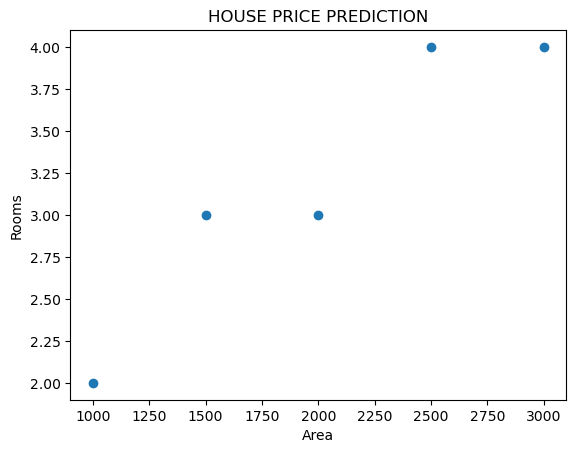

In [13]:
import matplotlib.pyplot as plt
plt.scatter(df['area'],df['rooms'])
plt.xlabel('Area')
plt.ylabel('Rooms')
plt.title('HOUSE PRICE PREDICTION')
plt.show()

#### STEP 7: MODEL EVALUATION

In this step, we evaluate the trained Linear Regression model's performance on unseen test data:

- **Mean Absolute Error (MAE)**: Measures the average absolute difference between predicted and actual prices
- **Interpretation**: A lower MAE indicates better model performance and more accurate predictions
- **Test Data**: We use X_test and y_test to evaluate how well the model generalizes to new data

Model evaluation is critical to assess whether the model is ready for deployment and to identify potential areas for improvement. The evaluation metric helps us understand the model's predictive accuracy in real-world scenarios.


In [16]:
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
error=mean_absolute_error(y_test,y_pred)
print("MEAN ABSOLUTE ERROR:",error)

MEAN ABSOLUTE ERROR: 5.820766091346741e-11
